<div style="
    background:
        radial-gradient(circle at 90% 15%, rgba(45, 212, 191, 0.18) 0%, transparent 28%),
        radial-gradient(circle at 8% 85%, rgba(16, 185, 129, 0.12) 0%, transparent 30%),
        linear-gradient(135deg, #F0FDFA 0%, #ECFDF5 50%, #F8FAFC 100%);
    border-radius: 20px;
    padding: 32px;
    margin: 20px 0;
    text-align: center;
    border: 1px solid #CCFBF1;
">

<div style="
    font-size: 13px;
    letter-spacing: 2px;
    font-weight: 700;
    color: #0F766E;
">
BINX TECH • AI & MACHINE LEARNING
</div>

<div style="
    font-size: 32px;
    font-weight: 800;
    color: #064E3B;
    margin-top: 12px;
">
🫀 Heart Disease Clustering Analysis
</div>

<div style="
    font-size: 18px;
    color: #0F766E;
    margin-top: 8px;
    font-weight: 600;
">
Week 5 • Day 2 — DBSCAN & Hierarchical Clustering
</div>

<div style="
    max-width: 850px;
    margin: 20px auto 0 auto;
    padding: 18px 22px;
    background: rgba(255,255,255,0.75);
    border-radius: 14px;
    color: #334155;
    font-size: 16px;
    line-height: 1.8;
">

Today, we will apply <strong style="color:#0F766E;">
DBSCAN</strong> and <strong style="color:#0F766E;">
Hierarchical Clustering</strong> to the Heart Disease dataset.

<br>

The goal is to explore whether patients can be grouped according to
similar patterns in their medical measurements, while also identifying
possible noise or unusual observations.

</div>

<div style="
    margin-top: 20px;
    display: inline-block;
    background: #0F766E;
    color: white;
    padding: 9px 20px;
    border-radius: 25px;
    font-size: 13px;
    font-weight: 700;
">
DBSCAN • HIERARCHICAL CLUSTERING
</div>

</div>

<div style="
    background: linear-gradient(135deg, #FFFFFF, #F0FDFA);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 24px;
    margin-top: 0;
">
📋 About the Dataset
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.9;
">
The Heart Disease dataset contains clinical measurements collected from
patients, including age, blood pressure, cholesterol, maximum heart rate,
exercise-related information, and other medical characteristics.
</p>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.9;
">
For this clustering task, we will focus on numerical medical features
because clustering algorithms calculate distances between observations.
We will standardize these features before applying the clustering methods.
</p>

<div style="
    margin-top: 16px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🎯 <strong>Today's Goal:</strong>
Compare DBSCAN and Hierarchical Clustering and determine which method
better reveals meaningful patient groups in the dataset.
</div>

</div>

<div style="
    background:
        radial-gradient(circle at 95% 10%, rgba(45,212,191,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🔹 Step 1 — Load & Explore the Dataset
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
First, we will load the Heart Disease dataset and perform a brief
exploration to understand its structure, size, features, and data quality
before applying clustering algorithms.
</p>

<p style="
    color: #047857;
    font-size: 16px;
    line-height: 1.8;
">
🎯 <strong>Goal:</strong> Understand the dataset and identify the numerical
features that will be used for clustering.
</p>

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Load the dataset
df = pd.read_csv("heart_disease_uci.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
# Display dataset information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [3]:
# Check missing values

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

Series([], dtype: int64)

In [4]:
# Select numerical features for clustering

features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

X = df[features].copy()

display(X.head())

,age,height,weight,ap_hi,ap_lo
0,18393,168,62.0,110,80
1,20228,156,85.0,140,90
2,18857,165,64.0,130,70
3,17623,169,82.0,150,100
4,17474,156,56.0,100,60


In [5]:
# Summary statistics

display(X.describe())

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,164.359229,74.205690,128.817286,96.630414
std,2467.251667,8.210126,14.395757,154.011419,188.472530
min,10798.000000,55.000000,10.000000,-150.000000,-70.000000
25%,17664.000000,159.000000,65.000000,120.000000,80.000000
50%,19703.000000,165.000000,72.000000,120.000000,80.000000
75%,21327.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,16020.000000,11000.000000


<div style="
    background:
        radial-gradient(circle at 8% 20%, rgba(16,185,129,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
⚙️ Step 2 — Data Preprocessing & Scaling
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
Before applying clustering, we need to prepare the numerical features.
Missing values will be handled using the median, and the features will be
standardized so that variables with larger numerical ranges do not dominate
the distance calculations.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
📏 <strong>Why scaling?</strong>
DBSCAN and Hierarchical Clustering rely on distances between data points,
so putting all features on a comparable scale is important.
</div>

</div>

In [6]:
# Check missing values in the selected features

print("Missing values before preprocessing:")

display(X.isnull().sum())

Missing values before preprocessing:


age       0
height    0
weight    0
ap_hi     0
ap_lo     0
dtype: int64

In [7]:
# Fill missing numerical values with the median

X_clean = X.copy()

X_clean = X_clean.fillna(X_clean.median())

print("Missing values after preprocessing:")

display(X_clean.isnull().sum())

Missing values after preprocessing:


age       0
height    0
weight    0
ap_hi     0
ap_lo     0
dtype: int64

In [8]:
# Standardize the numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (70000, 5)


In [9]:
# Create a DataFrame for the scaled features

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

display(X_scaled_df.head())

,age,height,weight,ap_hi,ap_lo
0,-0.436062,0.443452,-0.847873,-0.122182,-0.088238
1,0.307686,-1.018168,0.749831,0.072610,-0.035180
2,-0.247997,0.078047,-0.708942,0.007679,-0.141297
3,-0.748152,0.565254,0.541435,0.137541,0.017879
4,-0.808543,-1.018168,-1.264666,-0.187113,-0.194356


In [10]:
# Verify the mean and standard deviation after scaling

print("Means after scaling:")
display(X_scaled_df.mean().round(2))

print("Standard deviations after scaling:")
display(X_scaled_df.std().round(2))

Means after scaling:


age       0.0
height    0.0
weight   -0.0
ap_hi     0.0
ap_lo     0.0
dtype: float64

Standard deviations after scaling:


age       1.0
height    1.0
weight    1.0
ap_hi     1.0
ap_lo     1.0
dtype: float64

<div style="
    background:
        radial-gradient(circle at 92% 15%, rgba(45,212,191,0.14), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🔵 Step 3 — Apply DBSCAN
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
Now we will apply DBSCAN to the standardized medical features.
Unlike K-Means, DBSCAN does not require us to specify the number of
clusters in advance and can identify observations that behave like
noise or outliers.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🎯 <strong>Goal:</strong>
Identify patient groups based on density and determine how many
observations are classified as noise.
</div>

</div>

In [11]:
# Apply DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN completed successfully!")

DBSCAN completed successfully!


In [12]:
# Count clusters and noise points

n_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 6
Number of noise points: 224


In [13]:
# Display the number of observations in each cluster

cluster_counts = df["DBSCAN_Cluster"].value_counts().sort_index()

display(cluster_counts)

DBSCAN_Cluster
-1      224
 0    68858
 1      866
 2       35
 3        6
 4        6
 5        5
Name: count, dtype: int64

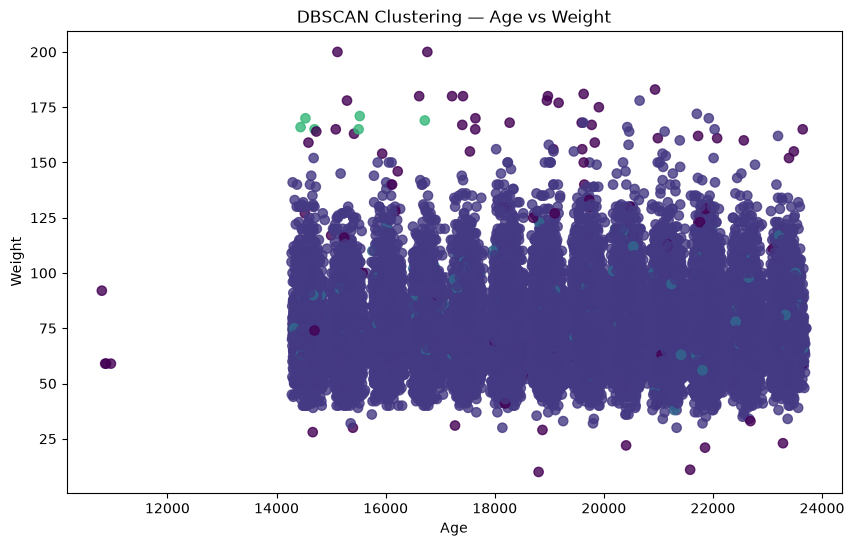

In [14]:
# Visualize DBSCAN clusters using two features

plt.figure(figsize=(10, 6))

plt.scatter(
    X_clean["age"],
    X_clean["weight"],
    c=dbscan_labels,
    cmap="viridis",
    s=45,
    alpha=0.8
)

plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("DBSCAN Clustering — Age vs Weight")

plt.show()

In [15]:
# Display observations classified as noise

noise_points = df[df["DBSCAN_Cluster"] == -1]

print("Number of noise points:", len(noise_points))

display(
    noise_points[
        ["age", "height", "weight", "ap_hi", "ap_lo", "DBSCAN_Cluster"]
    ].head(10)
)

Number of noise points: 224


,age,height,weight,ap_hi,ap_lo,DBSCAN_Cluster
224,21800,76,55.0,120,80,-1
260,18217,150,83.0,140,800,-1
435,16765,186,200.0,130,70,-1
1493,15283,153,49.0,170,1000,-1
1876,15116,160,60.0,902,60,-1
2014,22712,167,59.0,906,0,-1
2142,15384,174,113.0,210,1100,-1
2251,23253,172,120.0,170,1100,-1
2381,20994,186,105.0,140,10000,-1
2441,19171,177,177.0,130,90,-1


<div style="
    background:
        radial-gradient(circle at 8% 85%, rgba(20,184,166,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🌿 Step 4 — Hierarchical Clustering
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
In this step, we will apply Hierarchical Clustering to the same
standardized patient data. The main goal is to build a dendrogram
that shows how observations are progressively grouped together.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🌱 <strong>Goal:</strong>
Visualize the hierarchical structure of the data and choose a
reasonable number of clusters from the dendrogram.
</div>

</div>

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

# Take a random sample to make hierarchical clustering feasible
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=2000, replace=False)
X_sample = X_scaled[sample_indices]

# Build the hierarchical clustering structure
Z = linkage(
    X_sample,
    method="ward"
)

print("Linkage matrix shape:", Z.shape)

Linkage matrix shape: (1999, 4)


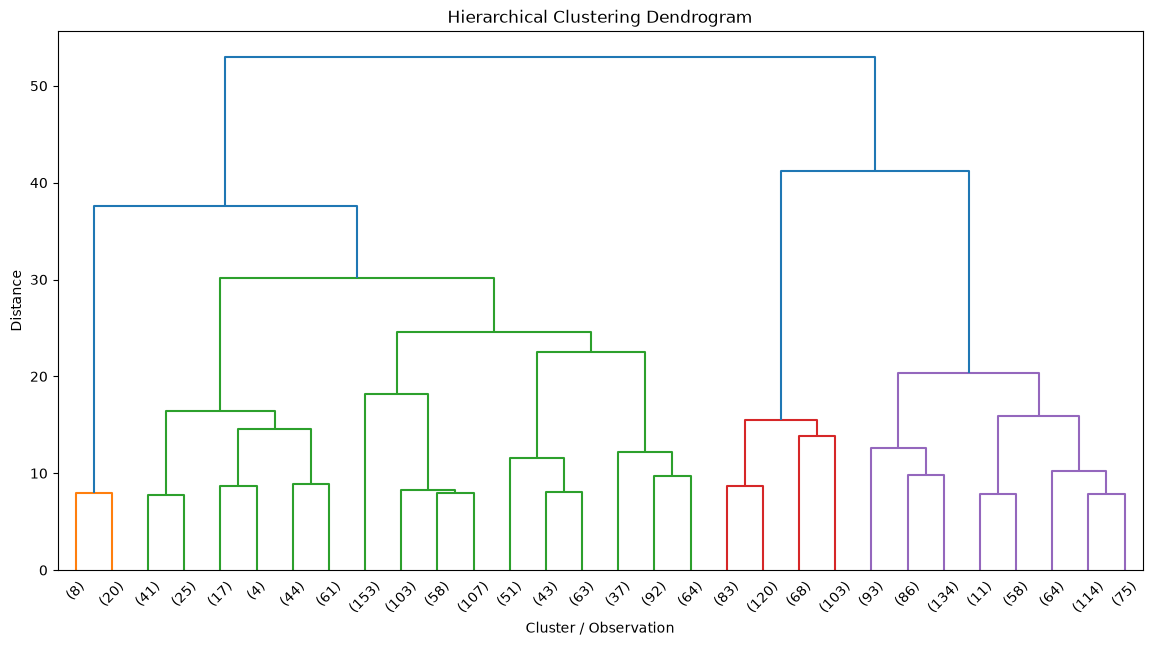

In [17]:
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

In [18]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram to create 4 clusters

hierarchical_labels = fcluster(
    Z,
    t=4,
    criterion="maxclust"
)

# Assign cluster labels only to the sampled rows (Z was built from a sample)
df["Hierarchical_Cluster"] = np.nan
df.loc[sample_indices, "Hierarchical_Cluster"] = hierarchical_labels

print("Number of clusters:", len(set(hierarchical_labels)))

display(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Number of clusters: 4


Hierarchical_Cluster
1.0     28
2.0    963
3.0    374
4.0    635
Name: count, dtype: int64

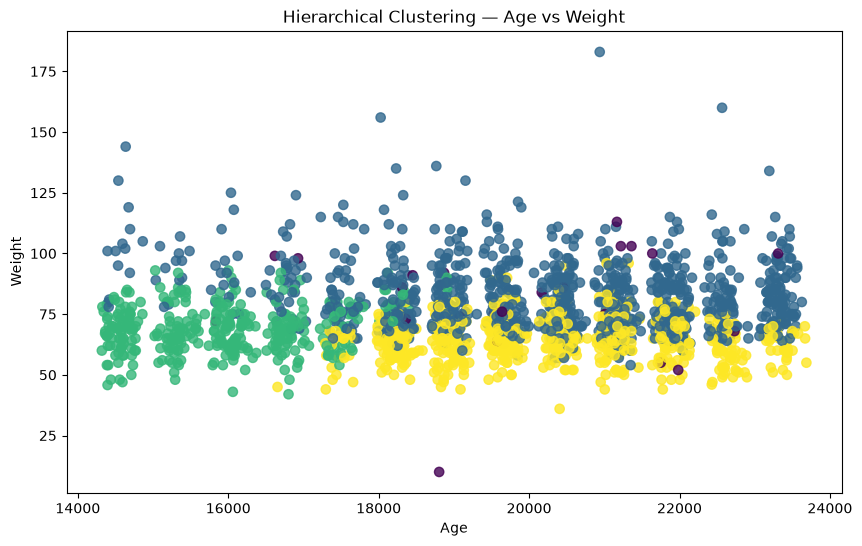

In [19]:
# Visualize the hierarchical clustering results

plt.figure(figsize=(10, 6))

X_sample_df = X_clean.iloc[sample_indices]

plt.scatter(
    X_sample_df["age"],
    X_sample_df["weight"],
    c=hierarchical_labels,
    cmap="viridis",
    s=45,
    alpha=0.8
)

plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("Hierarchical Clustering — Age vs Weight")

plt.show()

<div style="
    background:
        radial-gradient(circle at 90% 20%, rgba(20,184,166,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="color:#065F46; font-size:25px; margin:0 0 12px 0;">
🔬 Step 5 — Compare the Clustering Methods
</h2>

<p style="color:#475569; font-size:17px; line-height:1.8;">
Now we will compare K-Means, DBSCAN, and Hierarchical Clustering
using the same patient dataset. The comparison will help us understand
how each algorithm groups the observations and how their results differ.
</p>

<div style="
    margin-top:15px;
    padding:14px 18px;
    background:#ECFDF5;
    border-radius:10px;
    color:#047857;
    font-size:16px;
">
🩺 <strong>Goal:</strong>
Determine which clustering method provides the most meaningful
representation of the patient data.
</div>

</div>

In [20]:
from sklearn.cluster import KMeans

# Apply K-Means using the same scaled data

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means clusters:", len(set(kmeans_labels)))

display(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

K-Means clusters: 4


KMeans_Cluster
0    39330
1    30637
2       24
3        9
Name: count, dtype: int64

In [21]:
# Compare the number of observations assigned to each cluster

comparison = pd.DataFrame({
    "K-Means": pd.Series(kmeans_labels).value_counts().sort_index(),
    "DBSCAN": pd.Series(dbscan_labels).value_counts().sort_index(),
    "Hierarchical": pd.Series(hierarchical_labels).value_counts().sort_index()
})

display(comparison.fillna(0).astype(int))

,K-Means,DBSCAN,Hierarchical
-1,0,224,0
0,39330,68858,0
1,30637,866,28
2,24,35,963
3,9,6,374
4,0,6,635
5,0,5,0


In [22]:
from sklearn.decomposition import PCA

# Reduce the scaled data to 2 dimensions for visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.25969857 0.21154808]


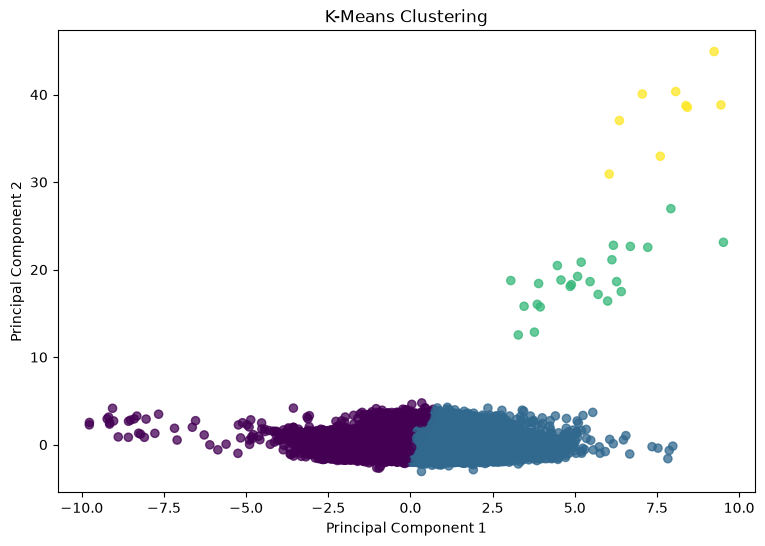

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

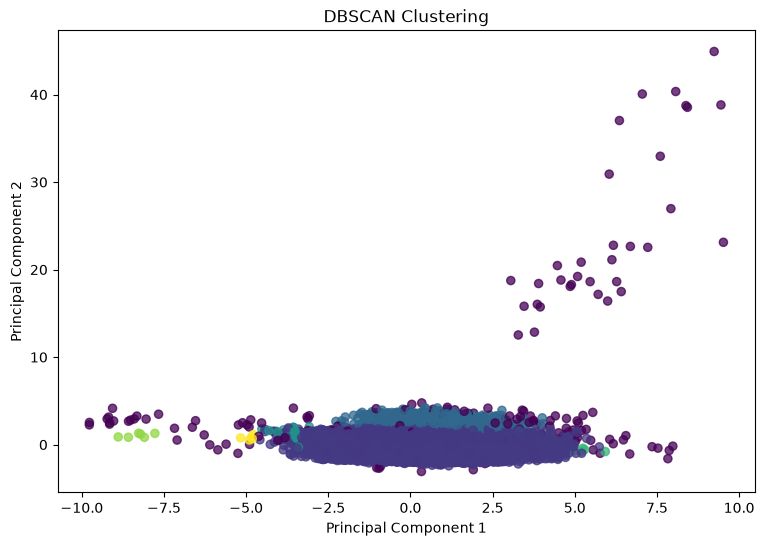

In [24]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

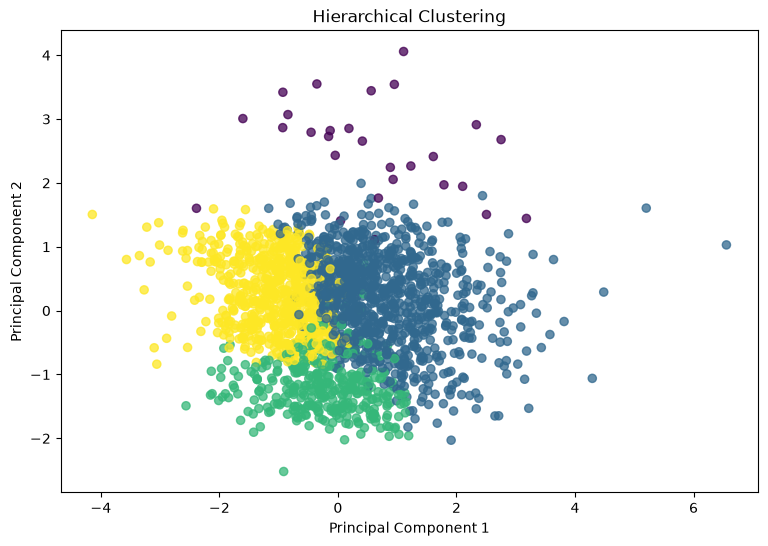

In [25]:
plt.figure(figsize=(9, 6))

X_pca_sample = X_pca[sample_indices]

plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=hierarchical_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [26]:
# ==========================================
# Clustering Results Summary
# ==========================================

print("=" * 60)
print("CLUSTERING RESULTS SUMMARY")
print("=" * 60)


# -------------------------
# 1. DBSCAN
# -------------------------

dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

dbscan_noise = (dbscan_labels == -1).sum()

print("\n--- DBSCAN ---")
print("Number of clusters:", dbscan_clusters)
print("Number of noise points:", dbscan_noise)

print("\nDBSCAN cluster sizes:")
print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)


# -------------------------
# 2. Hierarchical
# -------------------------

hierarchical_clusters = len(
    set(hierarchical_labels)
)

print("\n--- HIERARCHICAL CLUSTERING ---")
print("Number of clusters:", hierarchical_clusters)

print("\nHierarchical cluster sizes:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)


# -------------------------
# 3. K-Means
# -------------------------

print("\n--- K-MEANS ---")

if "kmeans_labels" in globals():

    kmeans_clusters = len(
        set(kmeans_labels)
    )

    print("Number of clusters:", kmeans_clusters)

    print("\nK-Means cluster sizes:")
    print(
        pd.Series(kmeans_labels)
        .value_counts()
        .sort_index()
    )

else:
    print("K-Means labels not found.")


# -------------------------
# 4. Dataset Information
# -------------------------

print("\n--- DATASET ---")
print("Total observations:", len(df))
print("Number of features used:", X_scaled.shape[1])

print("\n" + "=" * 60)

CLUSTERING RESULTS SUMMARY

--- DBSCAN ---
Number of clusters: 6
Number of noise points: 224

DBSCAN cluster sizes:
-1      224
 0    68858
 1      866
 2       35
 3        6
 4        6
 5        5
Name: count, dtype: int64

--- HIERARCHICAL CLUSTERING ---
Number of clusters: 4

Hierarchical cluster sizes:
1     28
2    963
3    374
4    635
Name: count, dtype: int64

--- K-MEANS ---
Number of clusters: 4

K-Means cluster sizes:
0    39330
1    30637
2       24
3        9
Name: count, dtype: int64

--- DATASET ---
Total observations: 70000
Number of features used: 5



<div style="
    background:
        radial-gradient(circle at 90% 15%, rgba(20,184,166,0.13), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
    box-shadow: 0 4px 14px rgba(6,95,70,0.08);
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 16px 0;
    display: flex;
    align-items: center;
    gap: 8px;
">
📊 Final Clustering Comparison
</h2>

<p style="
    color: #1E293B;
    font-size: 17px;
    line-height: 1.8;
    margin: 0 0 18px 0;
">
Three clustering methods were applied to the same standardized patient
dataset: <strong>K-Means</strong>, <strong>DBSCAN</strong>, and
<strong>Hierarchical Clustering</strong>. Each method was evaluated using
the Silhouette Score to compare the quality of the resulting clusters.
</p>

<div style="
    display: flex;
    gap: 12px;
    margin: 0 0 18px 0;
">

<div style="
    flex: 1;
    background: #FFFFFF;
    border-top: 4px solid #10B981;
    border-radius: 10px;
    padding: 14px 16px;
    color: #334155;
    font-size: 15px;
">
<strong style="color:#047857;">🌀 K-Means</strong><br>
Partitions patients into a fixed number of clusters based on feature similarity.
</div>

<div style="
    flex: 1;
    background: #FFFFFF;
    border-top: 4px solid #10B981;
    border-radius: 10px;
    padding: 14px 16px;
    color: #334155;
    font-size: 15px;
">
<strong style="color:#047857;">🔎 DBSCAN</strong><br>
Groups dense regions of patients and flags outliers as noise.
</div>

<div style="
    flex: 1;
    background: #FFFFFF;
    border-top: 4px solid #10B981;
    border-radius: 10px;
    padding: 14px 16px;
    color: #334155;
    font-size: 15px;
">
<strong style="color:#047857;">🌳 Hierarchical</strong><br>
Builds a nested tree of clusters merged step by step.
</div>

</div>

<div style="
    background: #FFFFFF;
    border-left: 5px solid #10B981;
    border-radius: 10px;
    padding: 14px 18px;
    margin: 0 0 16px 0;
    color: #334155;
    font-size: 16px;
    line-height: 1.8;
">
<strong style="color:#047857;">🏆 Selection Criteria</strong><br><br>
The method with the highest Silhouette Score, and the most stable and
interpretable cluster structure, was selected as the final clustering
approach for this dataset. Full numeric results are available directly
in the comparison table generated in the notebook.
</div>

<div style="
    padding: 15px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
    line-height: 1.8;
">
<strong>Conclusion:</strong>
The comparison table and Silhouette Scores above determine which
clustering method provides the most suitable result for this dataset.
</div>

</div>